In [2]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from config import tcr_embeddings_path, mhc_embeddings_path, peptide_embeddings_path, all_relations_path
import pickle

/home/tarnickil/.conda/envs/mgr_thesis/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
with open(tcr_embeddings_path, "rb") as f:
    tcr_embbedings = pickle.load(f)

with open(mhc_embeddings_path, "rb") as f:
    mhc_embbedings = pickle.load(f)

with open(peptide_embeddings_path, "rb") as f:
    peptide_embbedings = pickle.load(f)
    
with open(all_relations_path, "rb") as f:
    all_relations = pickle.load(f)

In [6]:
all_relations

,Donor,pMHC,TRAV,TRAJ,CDR3a,TRBV,TRBD,TRBJ,CDR3b,Binding,Count,Epitop,Name
0,donor1,A0201_RTLNAWVKV_Gag-protein_HIV_binder,TRAV1-1,TRAJ10,CAVEALTGGGNKLTF,TRBV5-6,TRBD2,TRBJ2-7,CASSAYTSGPKEQYF,Non-binding,1,Gag-protein_HIV_binder,TCR_1
1,donor1,A0201_RTLNAWVKV_Gag-protein_HIV_binder,TRAV1-1,TRAJ10,CAVPGITGGGNKLTF,TRBV5-4,NaN,TRBJ2-5,CASSLEQGPLQYF,Non-binding,1,WT1-(235-243)236M_Y_binder,TCR_2
2,donor1,A0201_RTLNAWVKV_Gag-protein_HIV_binder,TRAV1-1,TRAJ10,CAVRAPGGGNKLTF,TRBV5-4,NaN,TRBJ2-1,CASSLADNEQFF,Non-binding,1,BZLF1_EBV_binder,TCR_3
3,donor1,A0201_RTLNAWVKV_Gag-protein_HIV_binder,TRAV1-1,TRAJ10,CAVRDLGLTGGGNKLTF,TRBV9,TRBD2,TRBJ2-2,CASSVEKRGGAGELFF,Non-binding,1,NC_binder,TCR_4
4,donor1,A0201_RTLNAWVKV_Gag-protein_HIV_binder,TRAV1-1,TRAJ10,CAVRVGGGNKLTF,TRBV11-2,TRBD2,TRBJ1-1,CASSLDDVGGGFMNTEAFF,Non-binding,1,pp65_CMV_binder,TCR_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3362471,donor1,A0201_SLFNTVATL_Gag-protein_HIV_binder,TRAV12-2,TRAJ31,CAVNNARLMF,TRBV4-3,TRBD1,TRBJ2-3,CASSQGGGGTDTQYF,Binding,1,Gag-protein_HIV_binder,TCR_3622
3362472,donor2,A0201_SLFNTVATL_Gag-protein_HIV_binder,TRAV8-2,TRAJ24,CVVSDVSWGKLQF,TRBV19,NaN,TRBJ2-2,CASSSYTGELFF,Binding,1,WT1-(235-243)236M_Y_binder,TCR_36695
3362473,donor3,A0201_SLFNTVATL_Gag-protein_HIV_binder,TRAV22,TRAJ26,CAVGNYGQNFVF,TRBV4-1,NaN,TRBJ1-4,CASSQEGEKLFF,Binding,1,BZLF1_EBV_binder,TCR_45775
3362474,donor3,A0201_SLFNTVATL_Gag-protein_HIV_binder,TRAV29DV5,TRAJ33,CAASAVSNYQLIW,TRBV12-3,NaN,TRBJ2-3,CASSPTGNWNTDTQYF,Binding,1,NC_binder,TCR_47826


In [5]:
# tcr_embbedings[tcr_embbedings["TRAV"] == 'TRBV12-4']
# np.sum(tcr_embbedings["TRBD"].isna())/len(tcr_embbedings["TRBD"]) # 25% TCR nie posida TRBD
# tcr_embbedings[tcr_embbedings["TRBD"].isna() == True]
mhc_embbedings

,MHC,HLA_MHC,Pseudo_Seq,MHC_embeddings
0,A0201,HLA-A0201,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,"[-0.1341358, -0.15186317, 0.081519246, -0.1523..."
1,A2402,HLA-A2402,YSAMYEEKVAHTDENIAYLMFHYYTWAVQAYTGY,"[-0.08549553, -0.08714163, 0.12505846, -0.1118..."
2,B0801,HLA-B0801,YDSEYRNIFTNTDESNLYLSYNYYTWAVDAYTWY,"[-0.093745984, -0.032775197, -0.05226913, -0.0..."
3,B0801,HLA-B0801,YDSEYRNIFTNTDESNLYLSYNYYTWAVDAYTWY,"[-0.093745984, -0.032775197, -0.05226913, -0.0..."
4,A0101,HLA-A0101,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,"[-0.10563701, -0.11108949, 0.09293282, -0.1040..."
5,B0702,HLA-B0702,YYSEYRNIYAQTDESNLYLSYDYYTWAERAYEWY,"[-0.036238987, -0.03683884, -0.058688782, -0.0..."
6,A1101,HLA-A1101,YYAMYQENVAQTDVDTLYIIYRDYTWAAQAYRWY,"[-0.085412994, -0.06887053, 0.020493202, -0.04..."
7,NR(B0801),HLA-B0801,YDSEYRNIFTNTDESNLYLSYNYYTWAVDAYTWY,"[-0.093745984, -0.032775197, -0.05226913, -0.0..."
8,NR(B0801),HLA-B0801,YDSEYRNIFTNTDESNLYLSYNYYTWAVDAYTWY,"[-0.093745984, -0.032775197, -0.05226913, -0.0..."
9,A0301,HLA-A0301,YFAMYQENVAQTDVDTLYIIYRDYTWAELAYTWY,"[-0.1048726, -0.029446308, 0.04725359, -0.0378..."


In [23]:
with open(all_relations_path, "rb") as f:
    relations = pickle.load(f)
relations = relations[["Name", "TRAV", "TRAJ", "TRBV", "TRBD", "TRBJ"]] #"Name", "TRAV", "TRAJ", "TRBV", "TRBD", "TRBJ"
relations = relations.drop_duplicates(subset=["Name"])
relations["Name"].values

array(['TCR_1', 'TCR_2', 'TCR_3', ..., 'TCR_66955', 'TCR_66956',
       'TCR_66957'], shape=(66957,), dtype=object)

### UMAP DLA TCR

In [24]:
alpha_embedings = np.vstack(tcr_embbedings["Embeddings_alpha"])
beta_embedings = np.vstack(tcr_embbedings["Embeddings_beta"])
tcr_labels = tcr_embbedings["Name"].values
print(alpha_embedings.shape, beta_embedings.shape, tcr_labels.shape)

(66957, 640) (66957, 640) (66957,)


In [36]:
paired_reducer = umap.UMAP(n_components=2, min_dist=0.2, n_neighbors=70, metric='cosine')

paired_embeddings = np.hstack([alpha_embedings, beta_embedings])

# alpha_umap = paired_reducer.fit_transform(alpha_embedings)
# beta_umap = paired_reducer.fit_transform(beta_embedings)

paired_umap = paired_reducer.fit_transform(paired_embeddings)
mapper = paired_reducer.fit(paired_embeddings)

/tmp/ipykernel_2506005/3054869497.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


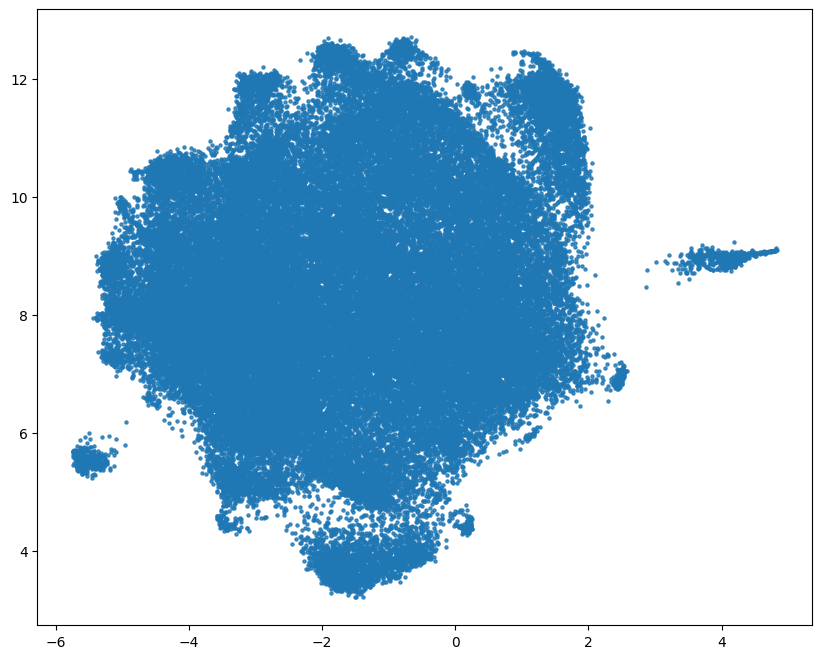

In [37]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    paired_umap[:,0],        # X-axis: alpha chain embeddings
    paired_umap[:,1],         # Y-axis: beta chain embeddings
    # c=tcr_labels,# Color by your labels (e.g., antigen specificity)
    s=5,            # Point size
    alpha=0.8,       # Transparency
    cmap='viridis'   # Color map
)

In [40]:
#"TRAV", "TRAJ", "TRBV", "TRBD", "TRBJ"
plot_df = pd.DataFrame({
    'UMAP1': paired_umap[:, 0],
    'UMAP2': paired_umap[:, 1],
    "Category": relations["TRAV"].values  # Convert to readable labels
})
print(len( paired_umap[:, 0]), len( paired_umap[:, 1]), len(relations["TRAJ"].values))

66957 66957 66957


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

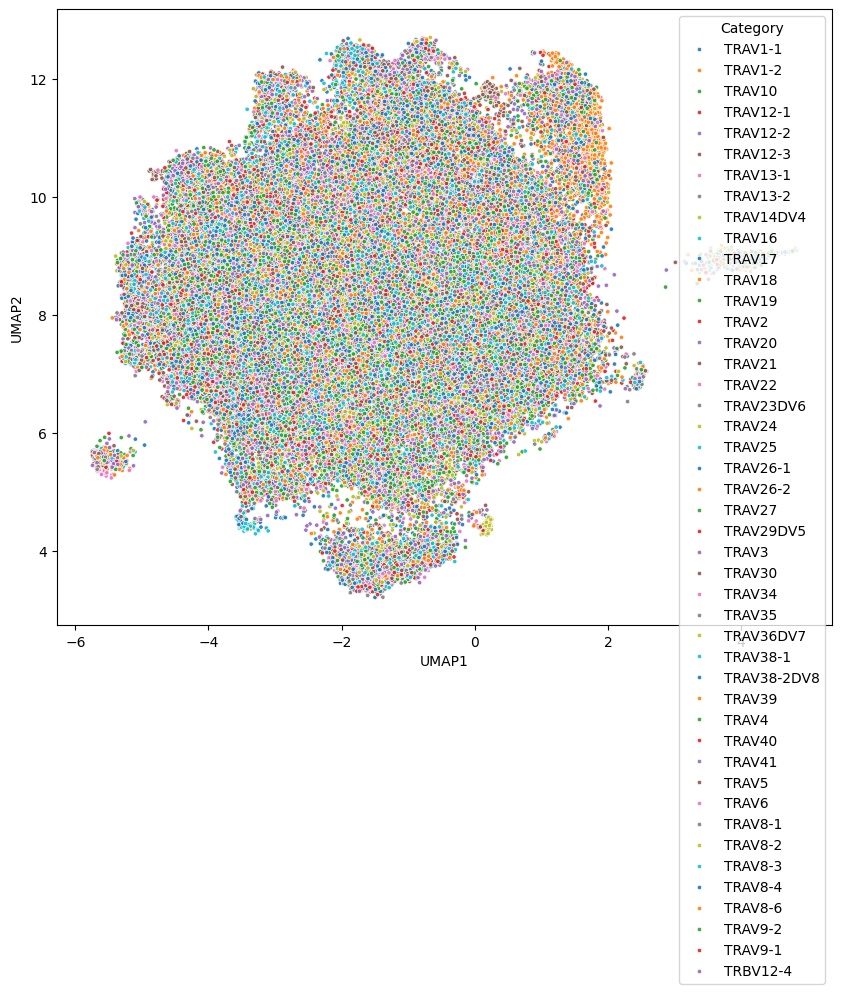

In [41]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x='UMAP1',
    y='UMAP2',
    hue='Category',          # Color by labels
    palette='tab10',      # Better color palette for categorical data
    s=10,                 # Point size
    alpha=0.9,            # Transparency
    edgecolor='w',        # White edge for better separation
    linewidth=0.5
)